In [1]:
# @title Instalacja zależności (Colab / Kaggle)
# WAŻNE: włącz dostęp do internetu przed uruchomieniem
#   Kaggle: Settings → Internet → On → Restart kernel
import subprocess, sys, shutil

def pip(*pkgs):
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q"] + list(pkgs),
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        print(f"PIP ERROR for {pkgs}:\n{result.stderr[-2000:]}")
    else:
        print(f"OK: {pkgs}")

pip("swig")
if shutil.which("swig") is None:
    subprocess.run(["apt-get", "install", "-y", "-q", "swig"], check=False)

pip("--upgrade", "gymnasium[box2d]")
pip("--upgrade", "stable-baselines3[extra]")
pip("moviepy")

if shutil.which("ffmpeg") is None:
    subprocess.run(["apt-get", "install", "-y", "-q", "ffmpeg"], check=False)
else:
    print("OK: ffmpeg (preinstalowany)")

import importlib
print(f"\nInstalacja zakończona. "
      f"gymnasium={importlib.metadata.version('gymnasium')}, "
      f"stable-baselines3={importlib.metadata.version('stable_baselines3')}")

OK: ('swig',)
OK: ('--upgrade', 'gymnasium[box2d]')
OK: ('--upgrade', 'stable-baselines3[extra]')
OK: ('moviepy',)
OK: ffmpeg (preinstalowany)

Instalacja zakończona. gymnasium=1.2.3, stable-baselines3=2.8.0


# Lab 5: Uczenie przez wzmacnianie w przestrzeniach ciągłych
#### Jan Jędra, Robert Jacak
**Środowisko:** LunarLanderContinuous-v3 &nbsp;|&nbsp; **Algorytm:** SAC (Soft Actor-Critic)

In [2]:
import base64
import time
from pathlib import Path

import gymnasium as gym
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch

from gymnasium.wrappers import RecordVideo
from IPython.display import HTML, display
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.results_plotter import load_results, ts2xy

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


def show_video(video_path):
    b64 = base64.b64encode(open(video_path, "rb").read()).decode()
    display(HTML(
        f'<video width="640" controls autoplay loop>'
        f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
        f'</video>'
    ))

2026-05-26 20:43:43.898575: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779828224.088659      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779828224.145100      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Device: cuda


In [3]:
# =====================================================================
# KONFIGURACJA — ustaw TEST_RUN = False dla pełnego treningu
# =====================================================================
TEST_RUN = False   # True = szybki test (~2 min), False = pełny trening (~1–2 godz.)

if TEST_RUN:
    N_RUNS          = 1        # docelowo 5
    TIMESTEPS       = 5_000    # docelowo 150_000
    N_ARCH_RUNS     = 2        # docelowo 3
    N_TIMING        = 200      # docelowo 1_000
    EVAL_EPISODES   = 2        # docelowo 10
    GRID_STEP       = 500
    LEARNING_STARTS = 500
    BUFFER_SIZE     = 20_000
    BATCH_SIZE      = 64
    MAX_EP_STEPS    = 500
else:
    N_RUNS          = 5
    TIMESTEPS       = 150_000
    N_ARCH_RUNS     = 3
    N_TIMING        = 1_000
    EVAL_EPISODES   = 10
    GRID_STEP       = 2_000
    LEARNING_STARTS = 5_000
    BUFFER_SIZE     = 200_000
    BATCH_SIZE      = 256
    MAX_EP_STEPS    = 1_000

GRID = np.arange(0, TIMESTEPS + 1, GRID_STEP)
print(f"{'[TEST RUN]' if TEST_RUN else '[FULL RUN]'}  "
      f"N_RUNS={N_RUNS}, TIMESTEPS={TIMESTEPS:,}, MAX_EP_STEPS={MAX_EP_STEPS}")

[FULL RUN]  N_RUNS=5, TIMESTEPS=150,000, MAX_EP_STEPS=1000


## Środowisko: LunarLanderContinuous-v3

LunarLanderContinuous-v3 to środowisko Gymnasium symulujące lądowanie modułu kosmicznego na wyznaczonej platformie. Przestrzeń obserwacji jest ciągła i ośmiowymiarowa: współrzędna pozioma i pionowa lądownika, prędkość pozioma i pionowa, kąt nachylenia oraz prędkość kątowa, a także dwa binarne wskaźniki kontaktu lewej i prawej nogi z podłożem. Przestrzeń akcji jest ciągła i dwuwymiarowa: pierwsza oś steruje silnikiem głównym (wartości ujemne → wyłączony, dodatnie → moc 50–100%), druga steruje silnikami bocznymi (wartości ujemne → lewy silnik, dodatnie → prawy silnik). Agent jest nagradzany za zbliżanie się do lądowiska i redukcję prędkości, karany za zużycie paliwa (silnik główny: −0.3/krok, boczne: −0.03/krok) oraz otrzymuje nagrodę końcową +100 za pomyślne lądowanie lub −100 za rozbicie. Epizod kończy się po wylądowaniu, rozbiciu lub po wyczerpaniu limitu kroków (domyślnie 1000).

## Algorytm: SAC (Soft Actor-Critic)

SAC (Haarnoja et al., 2018) to off-policy algorytm klasy actor-critic z maksymalizacją entropii polityki. Oprócz standardowej nagrody skumulowanej, SAC optymalizuje dodatkowy człon entropii αH(π), co zachęca agenta do eksploracji i zapobiega przedwczesnemu zbieganiu do lokalnych optimów. Parametr α (temperatura entropii) jest automatycznie dostrajany podczas treningu (`ent_coef="auto"`). SAC używa dwóch niezależnych sieci krytyka (twin Q-networks) — brana jest wartość minimalna, co redukuje przeszacowanie Q-wartości. Algorytm przechowuje przeszłe doświadczenia w buforze odpowiedzi (replay buffer) i losowo próbkuje minibatche do aktualizacji. Dzięki temu jest stabilny i efektywny próbkowo w środowiskach z ciągłą przestrzenią akcji. W implementacji SB3 używamy polityki `MlpPolicy` — wielowarstwowej sieci neuronowej (MLP) przetwarzającej ośmiowymiarowy wektor obserwacji bezpośrednio, bez warstw konwolucyjnych.

---
## Sekcja A — Porównanie 3 zestawów hiperparametrów
**Zmieniany hiperparametr:** `learning_rate` ∈ {1e-4, 3e-4, 1e-3}  
Pozostałe parametry stałe: `gamma=0.99`, `buffer_size`, `batch_size`, `learning_starts`, `train_freq=1`, `gradient_steps=1`, `ent_coef="auto"`  
Protokół: **10 niezależnych uruchomień** (seed 0–9) × **100 000 kroków** każde.

In [4]:
def make_env(max_ep_steps=None):
    _steps = max_ep_steps if max_ep_steps is not None else MAX_EP_STEPS
    return gym.make("LunarLanderContinuous-v3", max_episode_steps=_steps)


def make_venv(log_dir, seed, max_ep_steps=None):
    def _factory():
        return make_env(max_ep_steps=max_ep_steps)
    # MlpPolicy przyjmuje wektory obserwacji — VecTransposeImage niepotrzebny
    return make_vec_env(_factory, n_envs=1, monitor_dir=str(log_dir), seed=seed)


def interpolate_rewards(x, y, grid):
    if len(x) < 2:
        return np.full(len(grid), np.nan)
    return np.interp(grid, x, y)

In [5]:
env_time = make_env()
obs, _ = env_time.reset()
t0 = time.perf_counter()
for _ in range(N_TIMING):
    action = env_time.action_space.sample()
    obs, r, term, trunc, _ = env_time.step(action)
    if term or trunc:
        obs, _ = env_time.reset()
elapsed = time.perf_counter() - t0
env_time.close()

ms_per_step = elapsed / N_TIMING * 1000
steps_per_sec = N_TIMING / elapsed
print(f"Czas kroku środowiska: {ms_per_step:.3f} ms/krok  ({steps_per_sec:.0f} kroków/s)")
est_run_min = TIMESTEPS / steps_per_sec / 60
print(f"Szacowany czas 1 runu ({TIMESTEPS:,} kroków): {est_run_min:.1f} min")
print(f"Szacowany czas pełnego eksperymentu (3 LR × {N_RUNS} runów): {3 * N_RUNS * est_run_min:.0f} min")

Czas kroku środowiska: 0.123 ms/krok  (8143 kroków/s)
Szacowany czas 1 runu (150,000 kroków): 0.3 min
Szacowany czas pełnego eksperymentu (3 LR × 5 runów): 5 min


<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


In [6]:
LRS = [1e-4, 3e-4, 1e-3]

SAC_KWARGS = dict(
    gamma=0.99,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    batch_size=BATCH_SIZE,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",
    verbose=0,
    device=DEVICE,
)

all_rewards = {}  # lr -> np.array shape (N_RUNS, len(GRID))

for lr in LRS:
    tag = f"lr_{lr:.0e}".replace("-", "m")
    rewards_runs = []

    for seed in range(N_RUNS):
        log_dir = Path(f"./logs/sac_{tag}/run_{seed:02d}")
        log_dir.mkdir(parents=True, exist_ok=True)
        ckpt_dir = Path(f"./checkpoints/sac_{tag}/run_{seed:02d}")
        ckpt_dir.mkdir(parents=True, exist_ok=True)

        venv = make_venv(log_dir, seed=seed)
        model = SAC("MlpPolicy", venv, learning_rate=lr, seed=seed, **SAC_KWARGS)

        cb = CheckpointCallback(
            save_freq=TIMESTEPS,
            save_path=str(ckpt_dir),
            name_prefix=f"sac_{tag}_s{seed:02d}",
        )
        model.learn(total_timesteps=TIMESTEPS, callback=cb, progress_bar=False)
        model.save(str(ckpt_dir / "final"))
        venv.close()

        x, y = ts2xy(load_results(str(log_dir)), "timesteps")
        rewards_runs.append(interpolate_rewards(x, y, GRID))
        print(f"  lr={lr:.0e}  seed={seed:02d}  done")

    all_rewards[lr] = np.array(rewards_runs)
    print(f"[lr={lr:.0e}] finished — mean final reward: {np.nanmean(all_rewards[lr][:, -10:]):.1f}")

print("\nTraining complete.")

  lr=1e-04  seed=00  done
  lr=1e-04  seed=01  done
  lr=1e-04  seed=02  done
  lr=1e-04  seed=03  done
  lr=1e-04  seed=04  done
[lr=1e-04] finished — mean final reward: 152.9
  lr=3e-04  seed=00  done
  lr=3e-04  seed=01  done
  lr=3e-04  seed=02  done
  lr=3e-04  seed=03  done
  lr=3e-04  seed=04  done
[lr=3e-04] finished — mean final reward: 105.1
  lr=1e-03  seed=00  done
  lr=1e-03  seed=01  done
  lr=1e-03  seed=02  done
  lr=1e-03  seed=03  done
  lr=1e-03  seed=04  done
[lr=1e-03] finished — mean final reward: 140.3

Training complete.


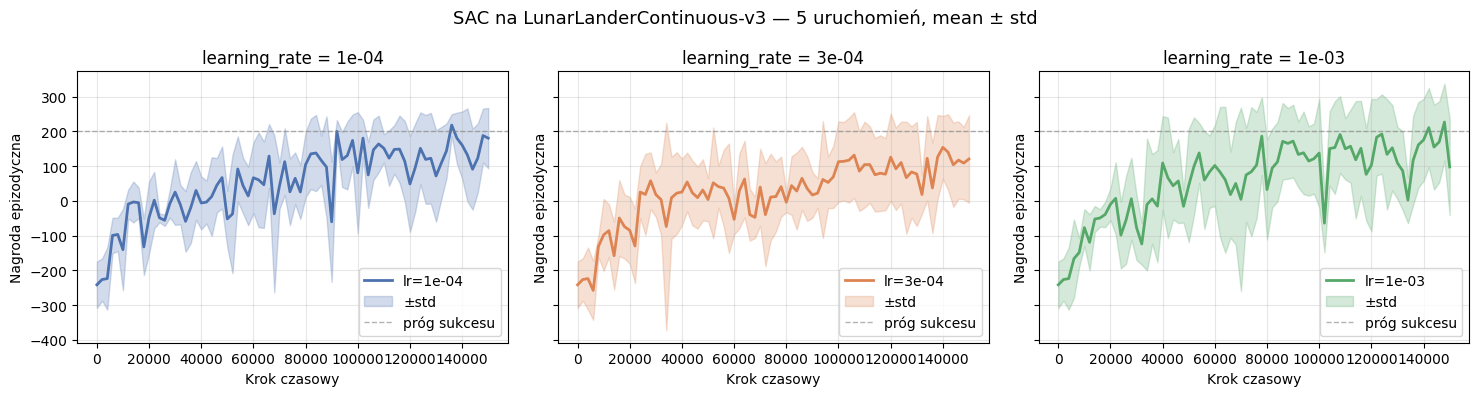


Średnia nagroda w ostatnich 10 punktach siatki:
  lr=1e-04:  mean=  152.9  std=100.9
  lr=3e-04:  mean=  105.1  std=118.4
  lr=1e-03:  mean=  140.3  std=132.5


In [7]:
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, lr, color in zip(axes, LRS, colors):
    data = all_rewards[lr]
    mean = np.nanmean(data, axis=0)
    std = np.nanstd(data, axis=0)
    ax.plot(GRID, mean, color=color, linewidth=2, label=f"lr={lr:.0e}")
    ax.fill_between(GRID, mean - std, mean + std, alpha=0.25, color=color, label="±std")
    ax.axhline(200, color="gray", linewidth=1, linestyle="--", alpha=0.6, label="próg sukcesu")
    ax.set_title(f"learning_rate = {lr:.0e}")
    ax.set_xlabel("Krok czasowy")
    ax.set_ylabel("Nagroda epizodyczna")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle(
    f"SAC na LunarLanderContinuous-v3 — {N_RUNS} uruchomień, mean ± std"
    + (" [TEST RUN]" if TEST_RUN else ""),
    fontsize=13,
)
plt.tight_layout()
plt.savefig("learning_curves_lr.png", dpi=150)
plt.show()

print("\nŚrednia nagroda w ostatnich 10 punktach siatki:")
for lr in LRS:
    m = np.nanmean(all_rewards[lr][:, -10:])
    s = np.nanstd(all_rewards[lr][:, -10:])
    print(f"  lr={lr:.0e}:  mean={m:7.1f}  std={s:.1f}")

### Analiza zestawów hiperparametrów

*(Wypełnij po wykonaniu pełnego treningu — poniżej szablon wniosków)*

**Rozważane hiperparametry i wartości:**

| Hiperparametr | Zestaw 1 | Zestaw 2 | Zestaw 3 |
|---|---|---|---|
| `learning_rate` | 1e-4 | 3e-4 | 1e-3 |
| `gamma` | 0.99 | 0.99 | 0.99 |
| `batch_size` | 256 | 256 | 256 |
| `buffer_size` | 200 000 | 200 000 | 200 000 |
| `ent_coef` | auto | auto | auto |

**Czas jednego kroku środowiska:** *(uzupełnij z komórki timing)*

**Wnioski:** *(uzupełnij po zobaczeniu wykresów)*
- Najwyższą średnią nagrodę osiągnął zestaw z `lr=...`
- Najniższe odchylenie standardowe wykazał `lr=...`
- `lr=1e-3`: duże kroki gradientu mogą destabilizować sieci Q-value → większa wariancja lub gorsze wyniki
- `lr=1e-4`: uczy się wolniej, ale stabilniej — może nie zdążyć w 100k krokach

---
## Sekcja B — Porównanie 2 architektur sieci

Obie architektury używają polityki `MlpPolicy` z tym samym wejściem (8D wektor obserwacji) i wyjściem (2D ciągła akcja). Różnią się rozmiarem ukrytych warstw aktora i krytyka.

**Architektura A — duża:**
- Wejście: 8D wektor [x, y, vx, vy, θ, ω, noga_L, noga_R]
- Linear(8→**256**) + ReLU → Linear(256→**256**) + ReLU
- Wyjście aktora: Linear(256→2) + tanh → akcja 2D [silnik główny, boczny]
- Krytyk (×2): Linear(8+2→256) + ReLU → Linear(256→256) + ReLU → Linear(256→1)

**Architektura B — mała:**
- Wejście: 8D wektor [x, y, vx, vy, θ, ω, noga_L, noga_R]
- Linear(8→**64**) + ReLU → Linear(64→**64**) + ReLU
- Wyjście aktora: Linear(64→2) + tanh → akcja 2D [silnik główny, boczny]
- Krytyk (×2): Linear(8+2→64) + ReLU → Linear(64→64) + ReLU → Linear(64→1)

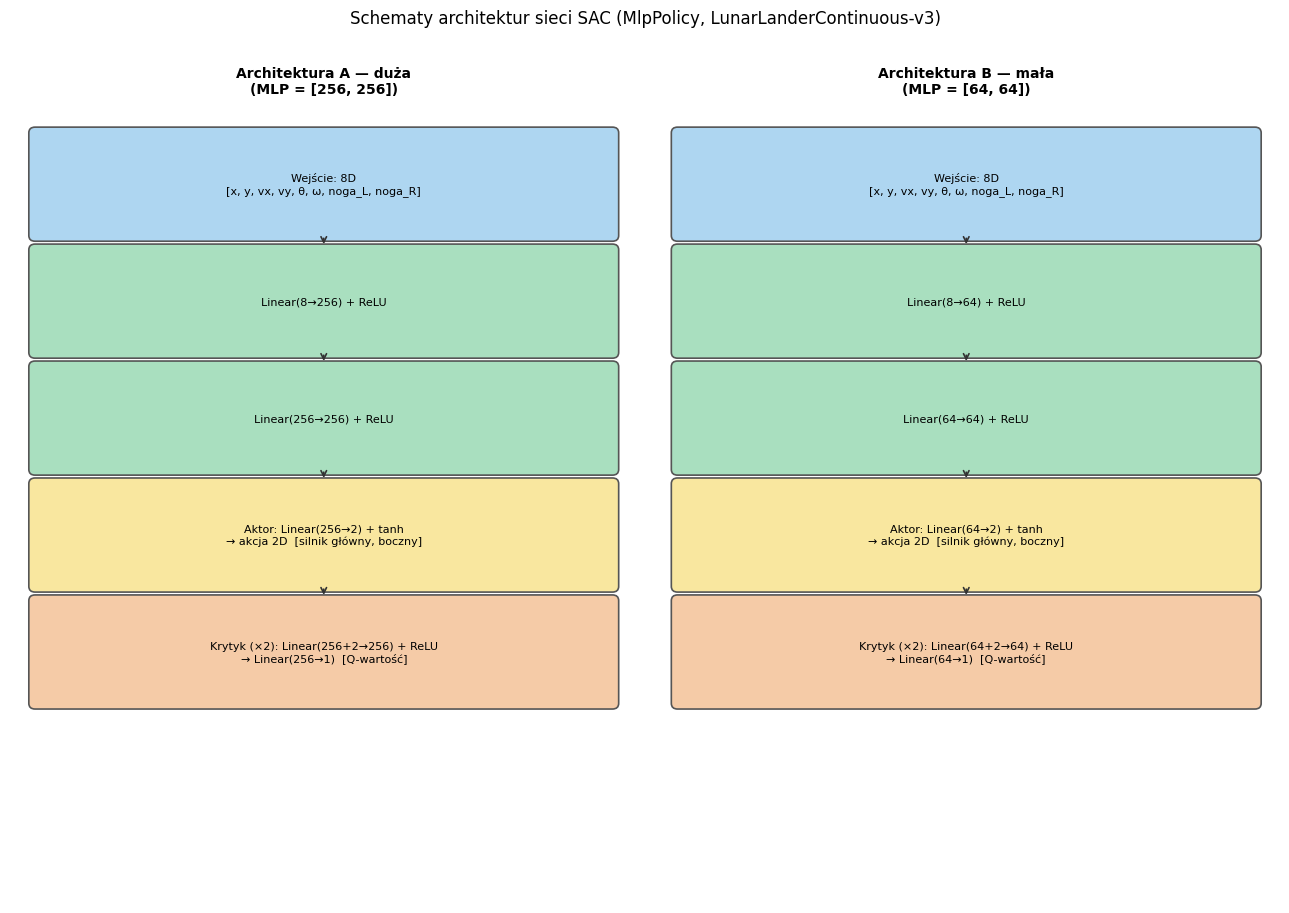

In [8]:
def draw_mlp_arch(ax, title, h):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 14)
    ax.axis("off")
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)

    layers = [
        ("Wejście: 8D\n[x, y, vx, vy, θ, ω, noga_L, noga_R]", "#AED6F1"),
        (f"Linear(8→{h}) + ReLU", "#A9DFBF"),
        (f"Linear({h}→{h}) + ReLU", "#A9DFBF"),
        (f"Aktor: Linear({h}→2) + tanh\n→ akcja 2D  [silnik główny, boczny]", "#F9E79F"),
        (f"Krytyk (×2): Linear({h}+2→{h}) + ReLU\n→ Linear({h}→1)  [Q-wartość]", "#F5CBA7"),
    ]

    box_h, gap, start_y = 1.8, 0.25, 13.5
    for i, (label, color) in enumerate(layers):
        y_top = start_y - i * (box_h + gap)
        ax.add_patch(mpatches.FancyBboxPatch(
            (0.4, y_top - box_h), 9.2, box_h,
            boxstyle="round,pad=0.1", facecolor=color, edgecolor="#555", linewidth=1.2,
        ))
        ax.text(5, y_top - box_h / 2, label, ha="center", va="center", fontsize=8)
        if i < len(layers) - 1:
            arr_y = y_top - box_h
            ax.annotate("", xy=(5, arr_y - gap + 0.05), xytext=(5, arr_y),
                        arrowprops=dict(arrowstyle="->", color="#333", lw=1.2))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 9))
draw_mlp_arch(ax1, "Architektura A — duża\n(MLP = [256, 256])", 256)
draw_mlp_arch(ax2, "Architektura B — mała\n(MLP = [64, 64])", 64)
plt.suptitle("Schematy architektur sieci SAC (MlpPolicy, LunarLanderContinuous-v3)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("arch_diagrams.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
BEST_LR = max(LRS, key=lambda lr: np.nanmean(all_rewards[lr][:, -10:]))
print(f"Najlepszy LR (z Sekcji A): {BEST_LR:.0e}")

ARCH_CONFIGS = {
    "A_large_256": {"net_arch": [256, 256]},
    "B_small_64":  {"net_arch": [64, 64]},
}

arch_rewards = {}

for arch_name, pkwargs in ARCH_CONFIGS.items():
    runs = []
    for seed in range(N_ARCH_RUNS):
        log_dir = Path(f"./logs/arch_{arch_name}/run_{seed:02d}")
        log_dir.mkdir(parents=True, exist_ok=True)
        ckpt_dir = Path(f"./checkpoints/arch_{arch_name}/run_{seed:02d}")
        ckpt_dir.mkdir(parents=True, exist_ok=True)

        venv = make_venv(log_dir, seed=seed)
        model = SAC(
            "MlpPolicy", venv,
            learning_rate=BEST_LR,
            policy_kwargs=pkwargs,
            seed=seed,
            **SAC_KWARGS,
        )
        model.learn(total_timesteps=TIMESTEPS, progress_bar=False)
        model.save(str(ckpt_dir / "final"))
        venv.close()

        x, y = ts2xy(load_results(str(log_dir)), "timesteps")
        runs.append(interpolate_rewards(x, y, GRID))
        print(f"  arch={arch_name}  seed={seed:02d}  done")

    arch_rewards[arch_name] = np.array(runs)
    m = np.nanmean(arch_rewards[arch_name][:, -10:])
    print(f"[{arch_name}] mean final reward: {m:.1f}")

print("\nArchitecture training complete.")

Najlepszy LR (z Sekcji A): 1e-04
  arch=A_large_256  seed=00  done
  arch=A_large_256  seed=01  done
  arch=A_large_256  seed=02  done
[A_large_256] mean final reward: 140.3
  arch=B_small_64  seed=00  done
  arch=B_small_64  seed=01  done
  arch=B_small_64  seed=02  done
[B_small_64] mean final reward: 66.0

Architecture training complete.


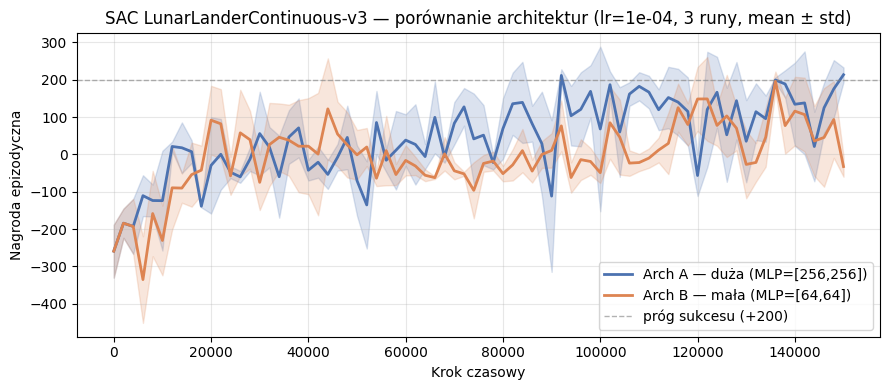


Średnia nagroda w ostatnich 10 punktach siatki:
  Arch A — duża (MLP=[256,256]): mean=140.3  std=95.6
  Arch B — mała (MLP=[64,64]): mean=66.0  std=105.7


In [10]:
arch_colors = {"A_large_256": "#4C72B0", "B_small_64": "#DD8452"}
arch_labels = {
    "A_large_256": "Arch A — duża (MLP=[256,256])",
    "B_small_64":  "Arch B — mała (MLP=[64,64])",
}

plt.figure(figsize=(9, 4))
for arch_name, data in arch_rewards.items():
    mean = np.nanmean(data, axis=0)
    std = np.nanstd(data, axis=0)
    c = arch_colors[arch_name]
    plt.plot(GRID, mean, color=c, linewidth=2, label=arch_labels[arch_name])
    plt.fill_between(GRID, mean - std, mean + std, alpha=0.2, color=c)

plt.axhline(200, color="gray", linewidth=1, linestyle="--", alpha=0.6, label="próg sukcesu (+200)")
plt.xlabel("Krok czasowy")
plt.ylabel("Nagroda epizodyczna")
plt.title(
    f"SAC LunarLanderContinuous-v3 — porównanie architektur (lr={BEST_LR:.0e}, {N_ARCH_RUNS} runy, mean ± std)"
    + (" [TEST RUN]" if TEST_RUN else "")
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("arch_comparison.png", dpi=150)
plt.show()

print("\nŚrednia nagroda w ostatnich 10 punktach siatki:")
for arch_name, data in arch_rewards.items():
    m = np.nanmean(data[:, -10:])
    s = np.nanstd(data[:, -10:])
    print(f"  {arch_labels[arch_name]}: mean={m:.1f}  std={s:.1f}")

---
## Sekcja C — Deterministyczny agent vs. krzywa uczenia

Wczytujemy model z najlepszym wynikiem z Sekcji A (najlepsza para `lr` + `seed`), uruchamiamy epizody z wyłączoną eksploracją (`deterministic=True`) i porównujemy wyniki z krzywą uczenia.

In [11]:
best_lr, best_seed, best_val = None, None, -np.inf
for lr in LRS:
    run_finals = np.nanmean(all_rewards[lr][:, -20:], axis=1)  # (N_RUNS,)
    # pomiń runy gdzie wszystko NaN
    valid = ~np.isnan(run_finals)
    if not valid.any():
        continue
    s = int(np.nanargmax(run_finals))
    v = run_finals[s]
    if v > best_val:
        best_val, best_lr, best_seed = v, lr, s

if best_lr is None:
    raise RuntimeError(
        "Brak kompletnych danych — żaden run nie zarejestrował zakończonych epizodów. "
        "Zwiększ TIMESTEPS lub zmniejsz MAX_EP_STEPS w komórce konfiguracyjnej."
    )

tag_best = f"lr_{best_lr:.0e}".replace("-", "m")
model_path = Path(f"./checkpoints/sac_{tag_best}/run_{best_seed:02d}/final.zip")
print(f"Najlepszy model: lr={best_lr:.0e}, seed={best_seed:02d}")
print(f"Śr. nagroda (koniec treningu): {best_val:.1f}")
print(f"Ścieżka: {model_path}")

model_eval = SAC.load(str(model_path), device=DEVICE)
print("Model wczytany.")

Najlepszy model: lr=3e-04, seed=04
Śr. nagroda (koniec treningu): 255.9
Ścieżka: checkpoints/sac_lr_3em04/run_04/final.zip
Model wczytany.


In [12]:
det_rewards = []
env_eval = make_env()

for ep in range(EVAL_EPISODES):
    obs, _ = env_eval.reset(seed=200 + ep)
    total_r = 0.0
    done = False
    while not done:
        action, _ = model_eval.predict(obs, deterministic=True)
        obs, r, term, trunc, _ = env_eval.step(action)
        total_r += r
        done = term or trunc
    det_rewards.append(total_r)
    print(f"  Epizod {ep:02d}: nagroda = {total_r:.1f}")

env_eval.close()
det_mean = np.mean(det_rewards)
det_std = np.std(det_rewards)
print(f"\nDeterministyczny agent — mean={det_mean:.1f}  std={det_std:.1f}")

  Epizod 00: nagroda = 185.4
  Epizod 01: nagroda = 293.6
  Epizod 02: nagroda = 254.3
  Epizod 03: nagroda = 17.0
  Epizod 04: nagroda = 293.9
  Epizod 05: nagroda = 273.9
  Epizod 06: nagroda = 301.9
  Epizod 07: nagroda = 247.5
  Epizod 08: nagroda = 228.7
  Epizod 09: nagroda = 303.7

Deterministyczny agent — mean=240.0  std=82.4


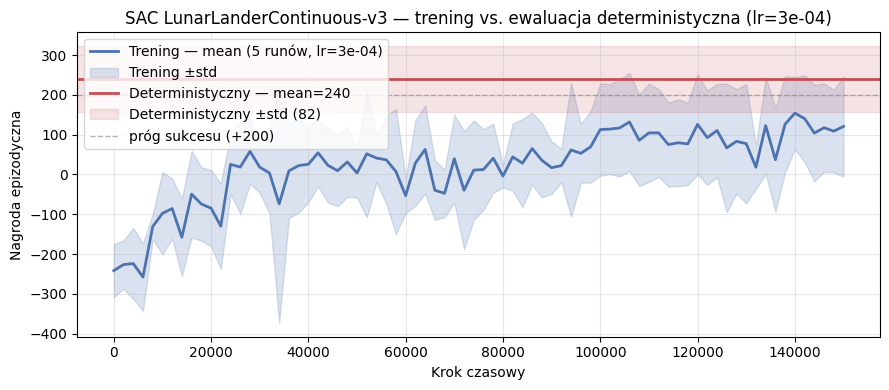

In [13]:
mean_curve = np.nanmean(all_rewards[best_lr], axis=0)
std_curve = np.nanstd(all_rewards[best_lr], axis=0)

plt.figure(figsize=(9, 4))
plt.plot(GRID, mean_curve, color="#4C72B0", linewidth=2,
         label=f"Trening — mean ({N_RUNS} runów, lr={best_lr:.0e})")
plt.fill_between(GRID, mean_curve - std_curve, mean_curve + std_curve,
                 alpha=0.2, color="#4C72B0", label="Trening ±std")
plt.axhline(det_mean, color="#C44E52", linewidth=2,
            label=f"Deterministyczny — mean={det_mean:.0f}")
plt.axhspan(det_mean - det_std, det_mean + det_std,
            alpha=0.15, color="#C44E52",
            label=f"Deterministyczny ±std ({det_std:.0f})")
plt.axhline(200, color="gray", linewidth=1, linestyle="--", alpha=0.6, label="próg sukcesu (+200)")
plt.xlabel("Krok czasowy")
plt.ylabel("Nagroda epizodyczna")
plt.title(
    f"SAC LunarLanderContinuous-v3 — trening vs. ewaluacja deterministyczna (lr={best_lr:.0e})"
    + (" [TEST RUN]" if TEST_RUN else "")
)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("det_vs_training.png", dpi=150)
plt.show()

In [14]:
video_dir = Path("./videos/best_agent")
video_dir.mkdir(parents=True, exist_ok=True)

env_vid = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")
env_vid = RecordVideo(
    env_vid,
    video_folder=str(video_dir),
    episode_trigger=lambda ep_id: True,
    disable_logger=True,
)

obs, _ = env_vid.reset(seed=42)
ep_reward = 0.0
done = False
while not done:
    action, _ = model_eval.predict(obs, deterministic=True)
    obs, r, term, trunc, _ = env_vid.step(action)
    ep_reward += r
    done = term or trunc

env_vid.close()
latest_video = sorted(video_dir.glob("*.mp4"))[-1]
print(f"Nagroda epizodu: {ep_reward:.1f}")
print(f"Wideo zapisane: {latest_video}")
show_video(str(latest_video))

/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /kaggle/working/videos/best_agent folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.11/dist-packages/moviepy/config_defaults.py:1: DeprecationWarning: invalid escape sequence '\P'
  """


Nagroda epizodu: 12.8
Wideo zapisane: videos/best_agent/rl-video-episode-0.mp4


---
## Kalibracja: ile kroków potrzebuje agent?

Jeden run SAC przez `CALIB_TIMESTEPS` kroków. Cel: zobaczyć kiedy agent zaczyna lądować poprawnie (nagroda > 200) — na tej podstawie dobieramy `TIMESTEPS` do porównania 30 runów w Sekcji A.

In [15]:
CALIB_TIMESTEPS = 200_000
CALIB_LR        = 3e-4

calib_log = Path("./logs/calib")
calib_log.mkdir(parents=True, exist_ok=True)
calib_ckpt = Path("./checkpoints/calib")
calib_ckpt.mkdir(parents=True, exist_ok=True)

calib_venv = make_venv(calib_log, seed=0)

calib_model = SAC(
    "MlpPolicy", calib_venv,
    learning_rate=CALIB_LR,
    gamma=0.99,
    buffer_size=200_000,
    learning_starts=5_000,
    batch_size=256,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",
    verbose=1,
    device=DEVICE,
    seed=0,
)

print(f"Kalibracja: STEPS={CALIB_TIMESTEPS:,}, LR={CALIB_LR}")

calib_cb = CheckpointCallback(
    save_freq=10_000,
    save_path=str(calib_ckpt),
    name_prefix="calib",
)
calib_model.learn(total_timesteps=CALIB_TIMESTEPS, callback=calib_cb, progress_bar=False)
calib_model.save(str(calib_ckpt / "final"))
calib_venv.close()
print("Trening kalibracyjny zakończony.")

Using cuda device
Kalibracja: STEPS=200,000, LR=0.0003
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 90       |
|    ep_rew_mean     | -300     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 2852     |
|    time_elapsed    | 0        |
|    total_timesteps | 360      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | -265     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 2887     |
|    time_elapsed    | 0        |
|    total_timesteps | 804      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 101      |
|    ep_rew_mean     | -239     |
| time/              |          |
|    episodes        | 12       |
|    fps             | 2905     |
|    time_elapsed    | 0   

In [16]:
# Podgląd checkpointu — uruchom w dowolnym momencie treningu kalibracyjnego
PREVIEW_STEPS = None   # None = najnowszy checkpoint; lub np. 50_000

calib_ckpt = Path("./checkpoints/calib")
ckpts = sorted(calib_ckpt.glob("calib_*_steps.zip"))

if not ckpts:
    print("Brak checkpointów — trening jeszcze nie zapisał żadnego (co 10k kroków).")
    print(f"Szukam w: {calib_ckpt.resolve()}")
else:
    if PREVIEW_STEPS is not None:
        target = calib_ckpt / f"calib_{PREVIEW_STEPS}_steps.zip"
        ckpt_path = target if target.exists() else ckpts[-1]
    else:
        ckpt_path = ckpts[-1]

    print(f"Dostępne checkpointy: {[c.name for c in ckpts]}")
    print(f"Ładuję: {ckpt_path.name}")

    preview_model = SAC.load(str(ckpt_path), device=DEVICE)

    video_preview = Path("./videos/preview")
    video_preview.mkdir(parents=True, exist_ok=True)

    env_prev = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")
    env_prev = RecordVideo(env_prev, video_folder=str(video_preview),
                           episode_trigger=lambda ep_id: True, disable_logger=True)

    obs, _ = env_prev.reset(seed=42)
    ep_r, done = 0.0, False
    while not done:
        action, _ = preview_model.predict(obs, deterministic=True)
        obs, r, term, trunc, _ = env_prev.step(action)
        ep_r += r
        done = term or trunc
    env_prev.close()

    latest = sorted(video_preview.glob("*.mp4"))[-1]
    print(f"Nagroda epizodu: {ep_r:.1f}")
    show_video(str(latest))

Dostępne checkpointy: ['calib_100000_steps.zip', 'calib_10000_steps.zip', 'calib_110000_steps.zip', 'calib_120000_steps.zip', 'calib_130000_steps.zip', 'calib_140000_steps.zip', 'calib_150000_steps.zip', 'calib_160000_steps.zip', 'calib_170000_steps.zip', 'calib_180000_steps.zip', 'calib_190000_steps.zip', 'calib_200000_steps.zip', 'calib_20000_steps.zip', 'calib_30000_steps.zip', 'calib_40000_steps.zip', 'calib_50000_steps.zip', 'calib_60000_steps.zip', 'calib_70000_steps.zip', 'calib_80000_steps.zip', 'calib_90000_steps.zip']
Ładuję: calib_90000_steps.zip


/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /kaggle/working/videos/preview folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Nagroda epizodu: -17.2


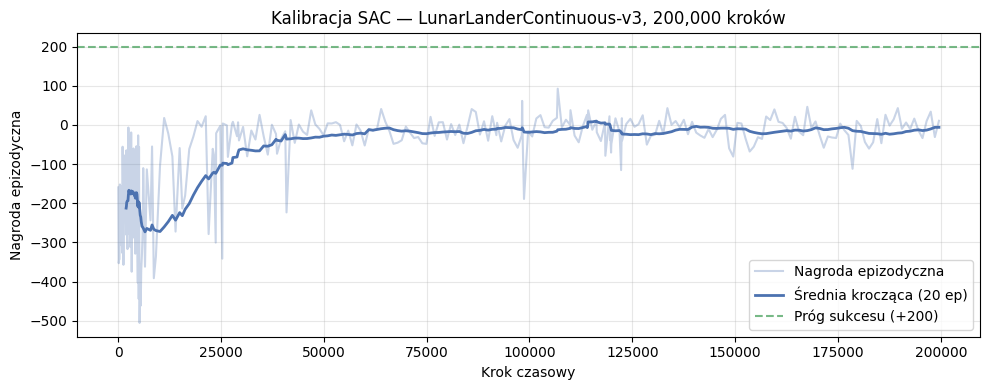

Epizodów łącznie: 280
Nagroda końcowa (ostatnie 20 ep): -6.1 ± 28.3
Maks. nagroda: 92.6
Agent nie osiągnął progu +200 — rozważ zwiększenie CALIB_TIMESTEPS


In [17]:
calib_log = Path("./logs/calib")
cx, cy = ts2xy(load_results(str(calib_log)), "timesteps")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cx, cy, alpha=0.3, color="#4C72B0", label="Nagroda epizodyczna")
if len(cy) >= 20:
    window = 20
    y_smooth = np.convolve(cy, np.ones(window) / window, mode="valid")
    ax.plot(cx[window - 1:], y_smooth, color="#4C72B0", linewidth=2,
            label=f"Średnia krocząca ({window} ep)")
ax.axhline(200, color="#55A868", linewidth=1.5, linestyle="--", alpha=0.8,
           label="Próg sukcesu (+200)")
ax.set_xlabel("Krok czasowy")
ax.set_ylabel("Nagroda epizodyczna")
ax.set_title(f"Kalibracja SAC — LunarLanderContinuous-v3, {CALIB_TIMESTEPS:,} kroków")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("calib_curve.png", dpi=150)
plt.show()

if len(cy) > 0:
    print(f"Epizodów łącznie: {len(cy)}")
    print(f"Nagroda końcowa (ostatnie 20 ep): {np.mean(cy[-20:]):.1f} ± {np.std(cy[-20:]):.1f}")
    print(f"Maks. nagroda: {np.max(cy):.1f}")
    smooth = np.convolve(cy, np.ones(20) / 20, mode="valid")
    above = np.where(smooth > 200)[0]
    if len(above) > 0:
        print(f"Agent osiąga próg +200 po ~{cx[above[0] + 19]:,} krokach")
    else:
        print("Agent nie osiągnął progu +200 — rozważ zwiększenie CALIB_TIMESTEPS")
else:
    print("Brak zakończonych epizodów")

In [18]:
calib_ckpt = Path("./checkpoints/calib")
final_path = calib_ckpt / "final.zip"
ckpts = sorted(calib_ckpt.glob("calib_*_steps.zip"))

if final_path.exists():
    load_path = final_path
    print("Ładuję: final.zip")
elif ckpts:
    load_path = ckpts[-1]
    print(f"Brak final.zip — ładuję ostatni checkpoint: {load_path.name}")
else:
    raise FileNotFoundError("Brak modeli w checkpoints/calib/ — uruchom najpierw komórkę treningową.")

calib_eval_model = SAC.load(str(load_path), device=DEVICE)

video_calib = Path("./videos/calib")
video_calib.mkdir(parents=True, exist_ok=True)

env_calib_vid = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")
env_calib_vid = RecordVideo(
    env_calib_vid,
    video_folder=str(video_calib),
    episode_trigger=lambda ep_id: True,
    disable_logger=True,
)

obs, _ = env_calib_vid.reset(seed=42)
ep_r = 0.0
done = False
while not done:
    action, _ = calib_eval_model.predict(obs, deterministic=True)
    obs, r, term, trunc, _ = env_calib_vid.step(action)
    ep_r += r
    done = term or trunc

env_calib_vid.close()
latest = sorted(video_calib.glob("*.mp4"))[-1]
print(f"Nagroda epizodu: {ep_r:.1f}")
show_video(str(latest))

Ładuję: final.zip


/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /kaggle/working/videos/calib folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Nagroda epizodu: -16.1
